# Multi-Output Regression for Java Ash HYSPLIT

Notebook ini membangun model multi-regressor untuk memprediksi target:
- `jarak_km`
- `luas_km2`
- `sudut_deg`
- `radius_km`

Rancangan analisis:
1. EDA ringkas dan validasi struktur data.
2. Pemilihan fitur otomatis dari kolom numerik.
3. Perbandingan dua model: **XGBoost** vs **RandomForest** (MultiOutputRegressor).
4. Evaluasi dengan **K-Fold CV** dan **holdout test**.
5. Metrik per target, feature importance, plot prediksi vs aktual.
6. Simpan model terbaik ke file `.pkl` dan contoh inferensi 1 baris.

In [1]:
import math
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import pydeck as pdk
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor


DATA_PATH = Path("java-ash-hysplit.csv")
MODEL_PATH = Path("best_multioutput_model.pkl")
TARGET_COLUMNS = ["jarak_km", "luas_km2", "sudut_deg", "radius_km"]
RANDOM_STATE = 42

EARTH_RADIUS_KM = 6371.0
SECTOR_SPREAD_DEG = 35.0
SECTOR_STEPS = 32
MAP_PROVIDER = "carto"
MAP_STYLE = "light"

LEVEL_SPECS = [
    (1, "Sangat Rendah", 1.00, [46, 139, 87, 90]),
    (2, "Rendah", 0.85, [154, 205, 50, 95]),
    (3, "Sedang", 0.65, [255, 215, 0, 105]),
    (4, "Tinggi", 0.45, [255, 140, 0, 120]),
    (5, "Sangat Tinggi", 0.25, [178, 34, 34, 130]),
]

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["id"])

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

df.head()

Dataset shape: (1707, 15)

Columns:
['timestamp', 'volcano_filter', 'alert_level', 'latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']

Missing values (top 10):
timestamp           0
volcano_filter      0
alert_level         0
latitude            0
longitude           0
elevation           0
tinggi_letusan_m    0
kec_angin_km_jam    0
arah_angin_deg      0
amplitudo           0
dtype: int64


,timestamp,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km
0,2024-06-11 07:34:00 UTC,Merapi,Yellow,-7.54194,110.44194,2968,1000.0,4.7,270.0,50.0,30.0,32.511505,614.390650,303.257335,18.304149
1,2024-01-24 08:56:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1000.0,8.0,135.0,51.0,168.0,27.761756,460.792988,37.901873,15.892819
2,2023-03-15 03:36:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1200.0,7.1,90.0,65.0,133.0,44.625714,614.214150,265.635506,23.934437
3,2023-03-13 22:50:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1500.0,3.2,135.0,70.0,160.0,22.998759,184.285530,288.108280,11.770659
4,2023-03-12 09:19:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,2500.0,8.3,315.0,70.0,145.0,39.159595,307.107075,270.462663,20.809694


In [3]:
required_targets = set(TARGET_COLUMNS)
missing_targets = sorted(required_targets.difference(df.columns))
if missing_targets:
    raise ValueError(f"Target column tidak ditemukan: {missing_targets}")

duplicate_rows = int(df.duplicated().sum())
print(f"Jumlah baris duplikat: {duplicate_rows}")

if "id" in df.columns:
    # id adalah identifier, tidak relevan untuk sinyal prediksi.
    df = df.drop(columns=["id"])

if "timestamp" in df.columns:
    timestamp_parsed = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["year"] = timestamp_parsed.dt.year
    df["month"] = timestamp_parsed.dt.month
    df["day"] = timestamp_parsed.dt.day
    df["hour"] = timestamp_parsed.dt.hour
    df["day_of_week"] = timestamp_parsed.dt.dayofweek
    hour_angle = 2 * math.pi * (df["hour"].fillna(0) / 24.0)
    df["hour_sin"] = hour_angle.apply(math.sin)
    df["hour_cos"] = hour_angle.apply(math.cos)
    df = df.drop(columns=["timestamp"])

for target_col in TARGET_COLUMNS:
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# Kolom konstan tidak memberi kontribusi ke model.
constant_cols = [
    col for col in df.columns
    if col not in TARGET_COLUMNS and df[col].nunique(dropna=False) <= 1
]
if constant_cols:
    print(f"Kolom konstan dihapus: {constant_cols}")
    df = df.drop(columns=constant_cols)

candidate_features = [col for col in df.columns if col not in TARGET_COLUMNS]
numeric_feature_columns = [
    col for col in candidate_features
    if pd.api.types.is_numeric_dtype(df[col])
]
categorical_feature_columns = [
    col for col in candidate_features
    if col not in numeric_feature_columns
]

if not candidate_features:
    raise ValueError("Tidak ada fitur yang bisa digunakan setelah preprocessing.")

X = df[candidate_features].copy()
y = df[TARGET_COLUMNS].copy()

valid_target_mask = y.notna().all(axis=1)
X = X.loc[valid_target_mask]
y = y.loc[valid_target_mask]

if len(X) < 100:
    raise ValueError(f"Data valid terlalu sedikit untuk training yang stabil: {len(X)} baris")

print(f"Jumlah fitur kandidat: {len(candidate_features)}")
print(f"Fitur numerik: {len(numeric_feature_columns)} | Fitur kategorikal: {len(categorical_feature_columns)}")
print(f"Contoh fitur numerik: {numeric_feature_columns[:10]}")
print(f"Contoh fitur kategorikal: {categorical_feature_columns[:10]}")
print(f"Shape final X: {X.shape}")
print(f"Shape final y: {y.shape}")

Jumlah baris duplikat: 0
Jumlah fitur kandidat: 17
Fitur numerik: 15 | Fitur kategorikal: 2
Contoh fitur numerik: ['latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'year', 'month']
Contoh fitur kategorikal: ['volcano_filter', 'alert_level']
Shape final X: (1707, 17)
Shape final y: (1707, 4)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

numeric_features = [
    col for col in X_train.columns if pd.api.types.is_numeric_dtype(X_train[col])
]
categorical_features = [col for col in X_train.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=600,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_base = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

et_base = ExtraTreesRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lin_base = LinearRegression()

candidate_models = {
    "xgboost": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("regressor", MultiOutputRegressor(xgb_base)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("regressor", MultiOutputRegressor(rf_base)),
        ]
    ),
    "extra_trees": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("regressor", MultiOutputRegressor(et_base)),
        ]
    ),
    "linear_baseline": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("regressor", MultiOutputRegressor(lin_base)),
        ]
    ),
}

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

comparison_rows = []
for model_name, model_pipeline in candidate_models.items():
    cv_scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
        },
        n_jobs=-1,
    )

    model_for_holdout = clone(model_pipeline)
    model_for_holdout.fit(X_train, y_train)
    holdout_pred = model_for_holdout.predict(X_test)

    comparison_rows.append(
        {
            "model": model_name,
            "cv_r2_mean": cv_scores["test_r2"].mean(),
            "cv_r2_std": cv_scores["test_r2"].std(),
            "cv_mae_mean": -cv_scores["test_mae"].mean(),
            "cv_rmse_mean": -cv_scores["test_rmse"].mean(),
            "holdout_r2": r2_score(y_test, holdout_pred),
            "holdout_mae": mean_absolute_error(y_test, holdout_pred),
            "holdout_rmse": mean_squared_error(y_test, holdout_pred) ** 0.5,
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["cv_r2_mean", "holdout_r2"],
    ascending=False,
)

best_model_name = comparison_df.iloc[0]["model"]
best_model = clone(candidate_models[best_model_name])
best_model.fit(X_train, y_train)

transformed_feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
feature_columns = transformed_feature_names.tolist()

comparison_df

,model,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_rmse_mean,holdout_r2,holdout_mae,holdout_rmse
2,extra_trees,0.724376,0.094206,32.744151,84.605075,0.813966,30.469809,120.801145
0,xgboost,0.705912,0.163243,33.899002,86.204613,0.837026,30.452980,97.575336
1,random_forest,0.682002,0.152433,33.400423,88.873364,0.821997,31.160695,109.246277
3,linear_baseline,0.269733,0.125712,73.563163,125.271355,0.462999,71.148172,167.541865


In [5]:
y_pred = best_model.predict(X_test)

holdout_metrics = []
for idx, target_name in enumerate(TARGET_COLUMNS):
    target_true = y_test.iloc[:, idx]
    target_pred = y_pred[:, idx]

    mse_value = mean_squared_error(target_true, target_pred)

    holdout_metrics.append(
        {
            "target": target_name,
            "mae": mean_absolute_error(target_true, target_pred),
            "rmse": mse_value ** 0.5,
            "r2": r2_score(target_true, target_pred),
        }
    )

holdout_metrics_df = pd.DataFrame(holdout_metrics)
print(f"Best model: {best_model_name}")
holdout_metrics_df

Best model: extra_trees


,target,mae,rmse,r2
0,jarak_km,3.888150,9.494113,0.855428
1,luas_km2,98.604924,238.080861,0.684453
2,sudut_deg,17.275424,39.625044,0.867919
3,radius_km,2.110739,5.374708,0.848064


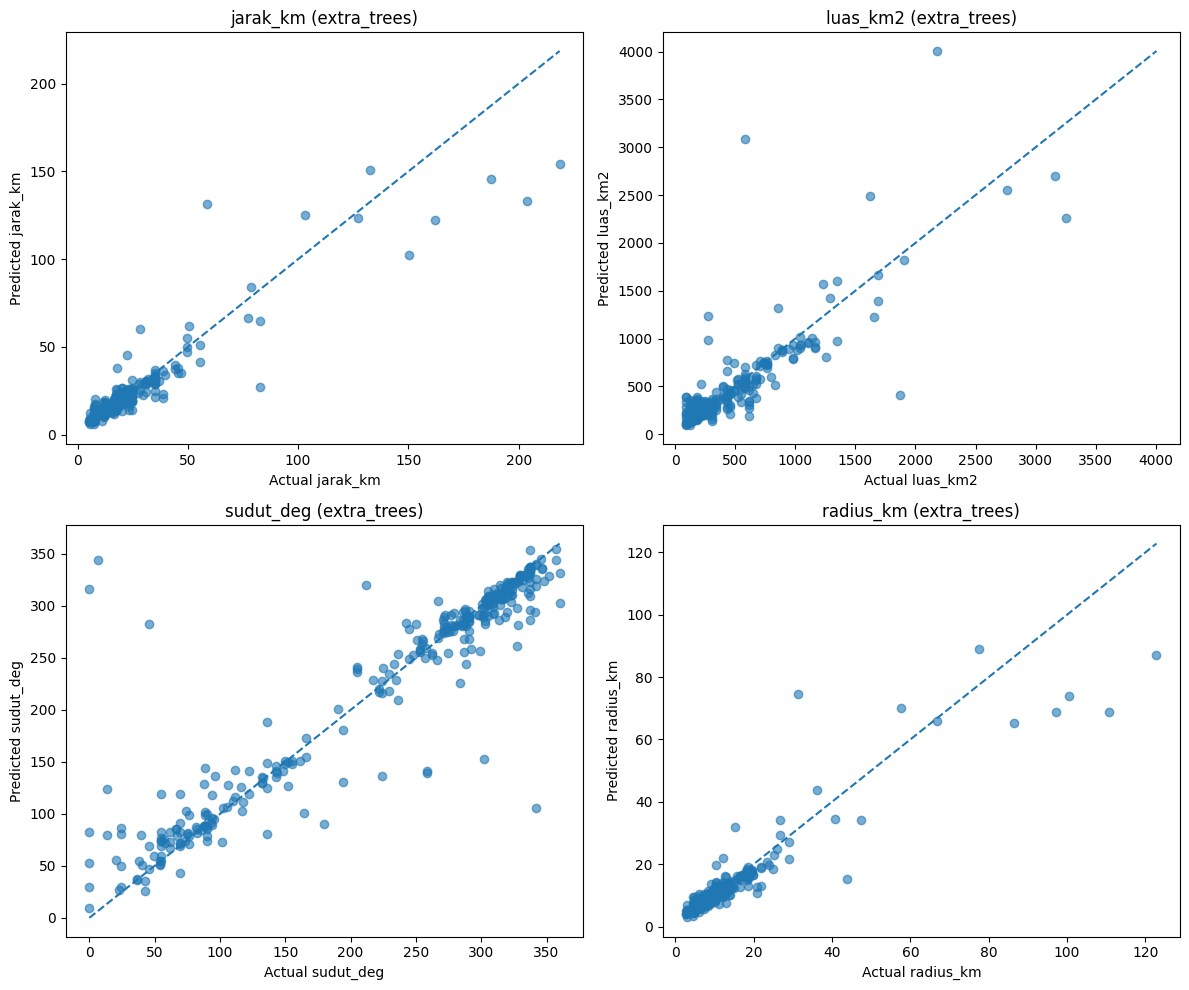

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, target_name in enumerate(TARGET_COLUMNS):
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]

    min_v = min(actual.min(), predicted.min())
    max_v = max(actual.max(), predicted.max())

    axes[i].scatter(actual, predicted, alpha=0.6)
    axes[i].plot([min_v, max_v], [min_v, max_v], linestyle="--")
    axes[i].set_xlabel(f"Actual {target_name}")
    axes[i].set_ylabel(f"Predicted {target_name}")
    axes[i].set_title(f"{target_name} ({best_model_name})")

plt.tight_layout()
plt.show()

In [7]:
sample_input = X_test.iloc[[0]].copy()
sample_prediction = best_model.predict(sample_input)

sample_result = pd.DataFrame(sample_prediction, columns=TARGET_COLUMNS)
print("Contoh inferensi 1 baris input:")
display(sample_result)

Contoh inferensi 1 baris input:


,jarak_km,luas_km2,sudut_deg,radius_km
0,25.080924,387.396109,306.242115,12.981754


In [8]:
first_target_estimator = best_model.named_steps["regressor"].estimators_[0]

if hasattr(first_target_estimator, "feature_importances_"):
    feature_importance = pd.Series(
        first_target_estimator.feature_importances_,
        index=feature_columns,
    ).sort_values(ascending=False)

    print("Top 15 feature importance:")
    display(feature_importance.head(15).to_frame("importance"))
else:
    feature_importance = pd.Series(dtype=float)
    print("Model terbaik tidak menyediakan feature_importances_.")

Top 15 feature importance:


,importance
num__tinggi_letusan_m,0.263038
num__month,0.133188
num__year,0.116510
cat__volcano_filter_Semeru,0.104966
num__day,0.078595
num__hour,0.052493
num__arah_angin_deg,0.029571
num__kec_angin_km_jam,0.027263
num__elevation,0.026391
num__hour_cos,0.024119


In [9]:
summary_df = pd.DataFrame(
    [
        {
            "best_model": best_model_name,
            "cv_r2_mean": comparison_df.iloc[0]["cv_r2_mean"],
            "holdout_r2": comparison_df.iloc[0]["holdout_r2"],
            "holdout_mae": comparison_df.iloc[0]["holdout_mae"],
            "holdout_rmse": comparison_df.iloc[0]["holdout_rmse"],
            "n_features": len(feature_columns),
            "n_train_rows": len(X_train),
            "n_test_rows": len(X_test),
        }
    ]
)

print("Ringkasan model terbaik:")
display(summary_df)
print("\nMetrik holdout per target:")
display(holdout_metrics_df)

Ringkasan model terbaik:


,best_model,cv_r2_mean,holdout_r2,holdout_mae,holdout_rmse,n_features,n_train_rows,n_test_rows
0,extra_trees,0.724376,0.813966,30.469809,120.801145,24,1365,342



Metrik holdout per target:


,target,mae,rmse,r2
0,jarak_km,3.888150,9.494113,0.855428
1,luas_km2,98.604924,238.080861,0.684453
2,sudut_deg,17.275424,39.625044,0.867919
3,radius_km,2.110739,5.374708,0.848064


In [10]:
artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_columns": feature_columns,
    "target_columns": TARGET_COLUMNS,
    "comparison": comparison_df,
    "holdout_metrics": holdout_metrics_df,
}

joblib.dump(artifact, MODEL_PATH)
print(f"Model terbaik tersimpan di: {MODEL_PATH.resolve()}")

Model terbaik tersimpan di: E:\Challange\Try\best_multioutput_model.pkl


In [11]:
def destination_point(lat: float, lon: float, distance_km: float, bearing_deg: float):
    lat1 = math.radians(lat)
    lon1 = math.radians(lon)
    bearing = math.radians(bearing_deg % 360)
    angular_distance = distance_km / EARTH_RADIUS_KM

    lat2 = math.asin(
        math.sin(lat1) * math.cos(angular_distance)
        + math.cos(lat1) * math.sin(angular_distance) * math.cos(bearing)
    )
    lon2 = lon1 + math.atan2(
        math.sin(bearing) * math.sin(angular_distance) * math.cos(lat1),
        math.cos(angular_distance) - math.sin(lat1) * math.sin(lat2),
    )

    return math.degrees(lat2), math.degrees(lon2)


def build_sector_polygon(origin_lat, origin_lon, radius_km, center_bearing_deg):
    start_bearing = center_bearing_deg - (SECTOR_SPREAD_DEG / 2)
    end_bearing = center_bearing_deg + (SECTOR_SPREAD_DEG / 2)

    points = [[origin_lon, origin_lat]]
    for i in range(SECTOR_STEPS + 1):
        t = i / SECTOR_STEPS
        bearing = start_bearing + t * (end_bearing - start_bearing)
        lat_pt, lon_pt = destination_point(origin_lat, origin_lon, radius_km, bearing)
        points.append([lon_pt, lat_pt])

    points.append([origin_lon, origin_lat])
    return points


reference_stats = {
    "radius_min": float(df["radius_km"].quantile(0.05)),
    "radius_max": float(df["radius_km"].quantile(0.95)),
    "area_min": float(df["luas_km2"].quantile(0.05)),
    "area_max": float(df["luas_km2"].quantile(0.95)),
}

if "sample_result" not in globals():
    sample_prediction = best_model.predict(sample_input)
    sample_result = pd.DataFrame(sample_prediction, columns=TARGET_COLUMNS)

origin_lat = float(sample_input.iloc[0]["latitude"])
origin_lon = float(sample_input.iloc[0]["longitude"])
radius_km = max(1.0, float(sample_result.iloc[0]["radius_km"]))
area_km2 = max(1.0, float(sample_result.iloc[0]["luas_km2"]))
center_bearing_deg = float(sample_result.iloc[0].get("sudut_deg", sample_input.iloc[0]["arah_angin_deg"]))

radius_norm = (radius_km - reference_stats["radius_min"]) / max(1e-6, (reference_stats["radius_max"] - reference_stats["radius_min"]))
area_norm = (area_km2 - reference_stats["area_min"]) / max(1e-6, (reference_stats["area_max"] - reference_stats["area_min"]))
base_severity = max(0.0, min(1.0, (0.6 * radius_norm) + (0.4 * area_norm)))

polygon_rows = []
summary_rows = []
for level, label, radius_factor, fill_color in LEVEL_SPECS:
    zone_radius = max(1.0, radius_km * radius_factor)
    proximity_weight = max(0.0, min(1.0, 1.15 - radius_factor))
    level_score = max(0.0, min(1.0, base_severity * (0.75 + 0.5 * proximity_weight)))

    polygon_rows.append(
        {
            "level": level,
            "label": label,
            "radius_km": round(zone_radius, 2),
            "impact_score": round(level_score, 3),
            "coordinates": build_sector_polygon(origin_lat, origin_lon, zone_radius, center_bearing_deg),
            "fill_color": fill_color,
        }
    )

    center_lat, center_lon = destination_point(origin_lat, origin_lon, zone_radius * 0.7, center_bearing_deg)
    summary_rows.append(
        {
            "level": level,
            "kategori": label,
            "radius_km": round(zone_radius, 2),
            "estimasi_luas_km2": round(area_km2 * (radius_factor**2), 2),
            "impact_score": round(level_score, 3),
            "pusat_lat": round(center_lat, 6),
            "pusat_lon": round(center_lon, 6),
        }
    )

polygon_df = pd.DataFrame(polygon_rows).sort_values("level")
summary_impact = pd.DataFrame(summary_rows).sort_values("level", ascending=False)

centerline_lat, centerline_lon = destination_point(origin_lat, origin_lon, radius_km, center_bearing_deg)
centerline_df = pd.DataFrame(
    [{"path": [[origin_lon, origin_lat], [centerline_lon, centerline_lat]]}]
)
points_df = pd.DataFrame(
    [
        {"name": "Pusat erupsi", "lat": origin_lat, "lon": origin_lon, "color": [20, 20, 20, 255], "radius": 550},
        {
            "name": "Arah dominan abu",
            "lat": centerline_lat,
            "lon": centerline_lon,
            "color": [178, 34, 34, 240],
            "radius": 420,
        },
    ]
)

map_layers = [
    pdk.Layer(
        "PolygonLayer",
        data=polygon_df,
        get_polygon="coordinates",
        get_fill_color="fill_color",
        get_line_color=[60, 60, 60, 140],
        line_width_min_pixels=1,
        pickable=True,
    ),
    pdk.Layer(
        "PathLayer",
        data=centerline_df,
        get_path="path",
        get_color=[180, 30, 30, 220],
        width_scale=1,
        width_min_pixels=2,
    ),
    pdk.Layer(
        "ScatterplotLayer",
        data=points_df,
        get_position="[lon, lat]",
        get_fill_color="color",
        get_radius="radius",
        pickable=True,
    ),
]

zoom = max(6.5, 10.7 - (math.log10(radius_km + 1.0) * 1.7))
deck = pdk.Deck(
    map_provider=MAP_PROVIDER,
    map_style=MAP_STYLE,
    initial_view_state=pdk.ViewState(
        latitude=origin_lat,
        longitude=origin_lon,
        zoom=zoom,
        pitch=35,
    ),
    layers=map_layers,
    tooltip={
        "html": "<b>Level:</b> {level} - {label}<br/><b>Radius:</b> {radius_km} km<br/><b>Skor:</b> {impact_score}",
        "style": {"backgroundColor": "#111111", "color": "#ffffff"},
    },
)

print("Peta sebaran abu berbasis prediksi (simulasi mendekati pola HYSPLIT):")
deck

print("Ringkasan titik/wilayah terdampak:")
display(summary_impact)

Peta sebaran abu berbasis prediksi (simulasi mendekati pola HYSPLIT):
Ringkasan titik/wilayah terdampak:


,level,kategori,radius_km,estimasi_luas_km2,impact_score,pusat_lat,pusat_lon
4,5,Sangat Tinggi,3.25,24.21,0.449,-8.095971,112.903356
3,4,Tinggi,5.84,78.45,0.411,-8.086307,112.890042
2,3,Sedang,8.44,163.67,0.374,-8.076643,112.876728
1,2,Rendah,11.03,279.89,0.337,-8.066979,112.863415
0,1,Sangat Rendah,12.98,387.40,0.309,-8.059730,112.853430
